In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("ggplot")


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vincentgupo/dengue-cases-in-the-philippines/ph_dengue_cases2016-2020.csv


# DATA EXTRACTION #

In [2]:
df = pd.read_csv("/kaggle/input/datasets/vincentgupo/dengue-cases-in-the-philippines/ph_dengue_cases2016-2020.csv")

df.head(3)

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0


### Renaming the columns ###

In [3]:
df = df.rename(columns={
    "Month":"month",
    "Year":"year",
    "Region":"region",
    "Dengue_Cases":"dengue_cases",
    "Dengue_Deaths":"dengue_deaths"
})

df.head(3)

,month,year,region,dengue_cases,dengue_deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0


### Describing the values ###

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   month          1020 non-null   object
 1   year           1020 non-null   int64 
 2   region         1020 non-null   object
 3   dengue_cases   1020 non-null   int64 
 4   dengue_deaths  1020 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 40.0+ KB


In [5]:
df.describe()

,year,dengue_cases,dengue_deaths
count,1020.000000,1020.000000,1020.000000
mean,2018.000000,1124.926471,16.513725
std,1.414907,1662.608878,96.358215
min,2016.000000,10.000000,0.000000
25%,2017.000000,247.750000,1.000000
50%,2018.000000,582.500000,3.000000
75%,2019.000000,1284.250000,7.000000
max,2020.000000,21658.000000,1651.000000


### Transforming the dataset ###

#### Remapping the month into numberss ####

In [6]:
df["month_num"] = df["month"].map({
    "January":1,
    "February":2,
    "March":3,
    "April":4,
    "May":5,
    "June":6,
    "July":7,
    "August":8,
    "September":9,
    "October":10,
    "November":11,
    "December":12
})

df["month_num"].value_counts()

month_num
1     85
2     85
3     85
4     85
5     85
6     85
7     85
8     85
9     85
10    85
11    85
12    85
Name: count, dtype: int64

#### Creating the datetime column ####

In [7]:
df["month_year"] = pd.to_datetime(
    dict(
        year=df["year"],
        month=df["month_num"],
        day=1
    )
)

df.head(5)

,month,year,region,dengue_cases,dengue_deaths,month_num,month_year
0,January,2016,Region I,705,1,1,2016-01-01
1,February,2016,Region I,374,0,2,2016-02-01
2,March,2016,Region I,276,0,3,2016-03-01
3,April,2016,Region I,240,2,4,2016-04-01
4,May,2016,Region I,243,1,5,2016-05-01


## EXPLORATORY DATA ANALYSIS ##

### Time Series (2016 - 2020) ###

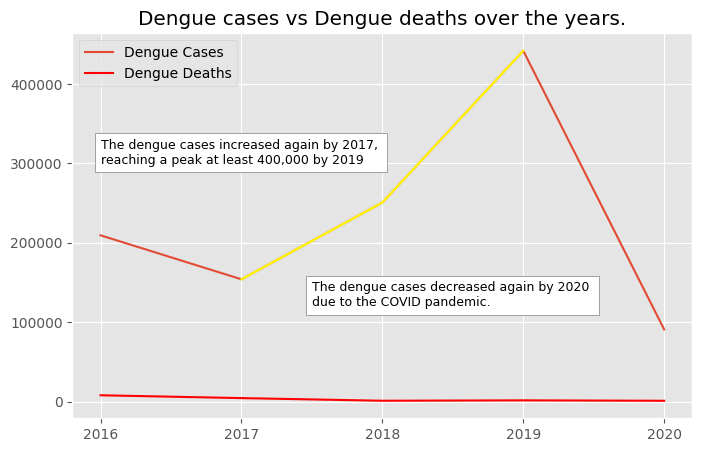

In [8]:
### Plotting dengue cases and deaths per year

## df

viz_df = df.groupby("year")[["dengue_cases","dengue_deaths"]].sum()
viz_df = viz_df.reset_index()

### axes

viz_df_x = viz_df["year"]
viz_df_y = viz_df["dengue_cases"]
viz_df_z = viz_df["dengue_deaths"]

### plotting 

plt.figure(figsize=(8,5))
plt.plot(
    viz_df_x,
    viz_df_y,
    label="Dengue Cases"
)

plt.plot(
    viz_df_x,
    viz_df_z,
    label="Dengue Deaths",
    color="red"
)


### annotate

viz_df_annot = df.groupby("year")["dengue_cases"].sum()
viz_df_annot = viz_df_annot.reset_index()
viz_df_annot = viz_df_annot[(viz_df_annot["year"] >= 2017) & (viz_df_annot["year"] <= 2019)]


viz_df_annot_x = viz_df_annot["year"]
viz_df_annot_y = viz_df_annot["dengue_cases"]

plt.plot(
    viz_df_annot_x,
    viz_df_annot_y,
    color="yellow"
)

plt.text(
    2016,300_000,
    "The dengue cases increased again by 2017, \nreaching a peak at least 400,000 by 2019",
    size=9,
    bbox=dict(
        facecolor="white",
        edgecolor="gray"
    )
)

plt.text(
    2017.5,120_000,
    "The dengue cases decreased again by 2020 \ndue to the COVID pandemic.",
    size=9,
    bbox=dict(
        facecolor="white",
        edgecolor="gray"
    )
)

plt.title("Dengue cases vs Dengue deaths over the years.")


plt.xticks(viz_df_x)
plt.legend()

plt.show()

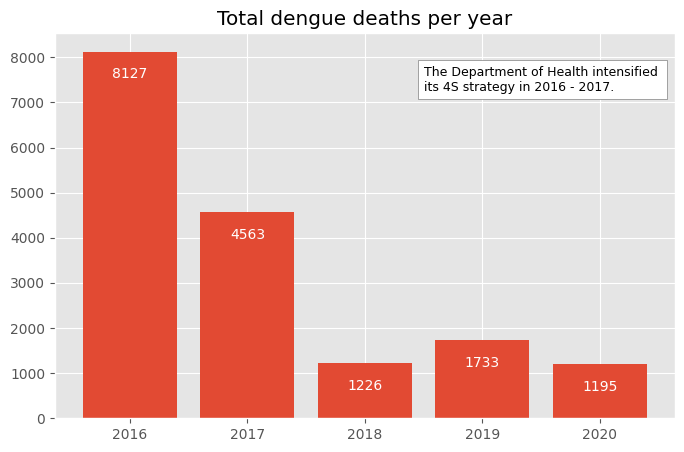

In [9]:
## Visualizing the total dengue cases per year

## axes

viz_df = df.groupby("year")["dengue_deaths"].sum()
viz_df = pd.DataFrame(viz_df).reset_index()

viz_df_x = viz_df["year"]
viz_df_y = viz_df["dengue_deaths"]

## chart

plt.figure(figsize=(8,5))
plt.bar(viz_df_x, viz_df_y)

## annotate

plt.title("Total dengue deaths per year")

for x, y in zip(viz_df_x, viz_df_y):
    plt.text(
        x, y - 500,
        y,
        color="white",
        va="center",
        ha="center"
    )

plt.text(
    2018.5, 7500,
    "The Department of Health intensified \nits 4S strategy in 2016 - 2017.",
    va="center",
    size=9,
    bbox=dict(
        facecolor="white",
        edgecolor="gray"
    )
)


plt.show()

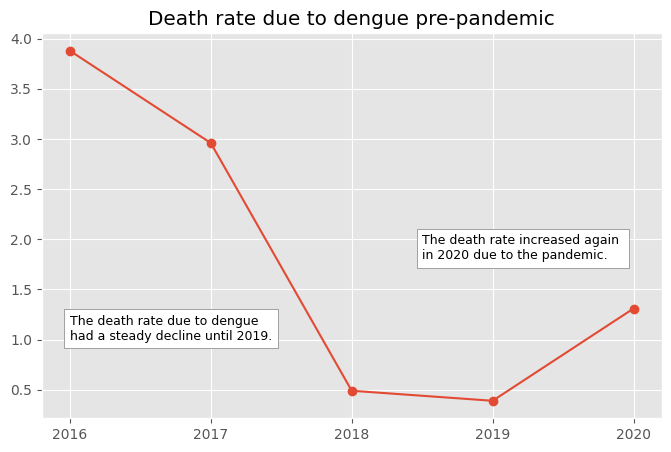

In [10]:
### death rate per year


## axes
viz_df = df.groupby("year")[["dengue_deaths", "dengue_cases"]].sum()
viz_df = viz_df.reset_index()
viz_df["dengue_death_rate"] = (viz_df["dengue_deaths"] / viz_df["dengue_cases"]) * 100
viz_df["dengue_death_rate"] = round(viz_df["dengue_death_rate"], 2)

viz_df_x = viz_df["year"]
viz_df_y = viz_df["dengue_death_rate"]

## charts

plt.figure(figsize=(8,5))

plt.plot(
    viz_df_x,
    viz_df_y,
    marker="o"
)

plt.xticks(viz_df_x)

## annotate

plt.text(
    2016, 1.0,
    "The death rate due to dengue \nhad a steady decline until 2019.",
    bbox=dict(
        facecolor="white",
        edgecolor="gray"
    ),
    size=9
)

plt.text(
    2018.5, 1.8,
    "The death rate increased again \nin 2020 due to the pandemic.",
    bbox=dict(
        facecolor="white",
        edgecolor="gray"
    ),
    size=9
)

plt.title("Death rate due to dengue pre-pandemic")

plt.show()

## Analysis of NCR Dengue Case Trends ##

#### Isolating the NCR dataset ####

In [11]:
## isolating NCR data
df_ncr = df[df["region"] == "NCR"]

df_ncr.head(5)

,month,year,region,dengue_cases,dengue_deaths,month_num,month_year
840,January,2016,NCR,1261,4,1,2016-01-01
841,February,2016,NCR,999,7,2,2016-02-01
842,March,2016,NCR,730,3,3,2016-03-01
843,April,2016,NCR,448,2,4,2016-04-01
844,May,2016,NCR,414,0,5,2016-05-01


#### Plotting the yearly dengue cases for NCR ####

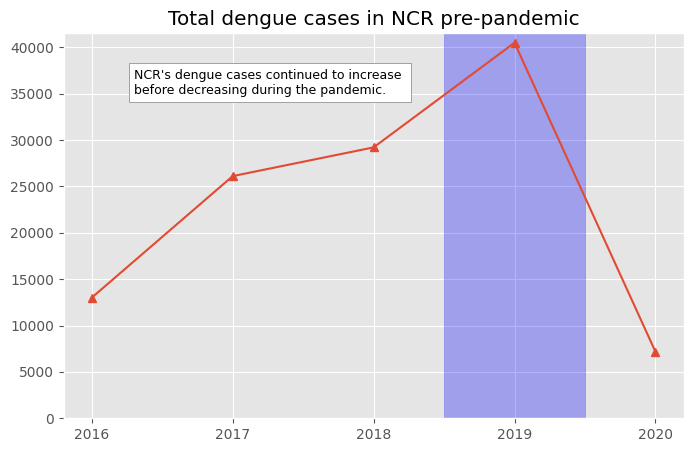

In [12]:
## yearly dengue cases 

## axes

viz_df = df_ncr.groupby("year")["dengue_cases"].sum()
viz_df = viz_df.reset_index()

viz_df_x = viz_df["year"]
viz_df_y = viz_df["dengue_cases"]

## plot

plt.figure(figsize=(8,5))
plt.plot(
    viz_df_x,
    viz_df_y,
    marker="^"
)

## annotate

plt.xticks(viz_df_x)
plt.title("Total dengue cases in NCR pre-pandemic")

plt.text(
    2016.3, 35_000,
    "NCR's dengue cases continued to increase \nbefore decreasing during the pandemic.",
    bbox=dict(
        facecolor="white",
        edgecolor="gray"
    ),
    size=9
)

plt.ylim(0,41_500)

plt.fill_between(
    (2018.5, 2019.5),
    41_500,
    color="blue",
    alpha=0.3
)

plt.show()

### Plotting the YoY NCR dengue cases ###

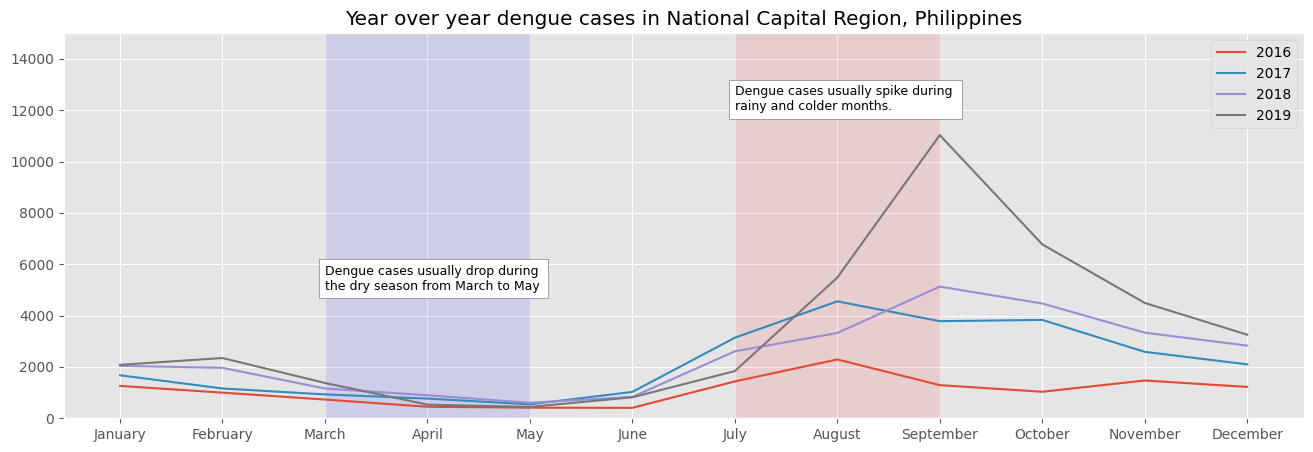

In [13]:
## plotting the yoy cases

## plot

plt.figure(figsize=(16,5))

for year in range(0, 4):
    plot_year = 2016 + year

    viz_df = df_ncr[df_ncr["year"] == plot_year]
    viz_df_x = viz_df["month"]
    viz_df_y = viz_df["dengue_cases"]
    plt.plot(viz_df_x, viz_df_y, label=plot_year)



## annotate



plt.title("Year over year dengue cases in National Capital Region, Philippines")
plt.ylim(0, 15_000)
plt.fill_between(
    (2, 4),
    15_000,
    color="blue",
    alpha=0.1
)

plt.fill_between(
    (6, 8),
    15_000,
    color="red",
    alpha=0.1
)

plt.text(
    2, 5_000,
    "Dengue cases usually drop during \nthe dry season from March to May",
    size=9,
    bbox=dict(
        facecolor="white",
        edgecolor="gray"
    )
)

plt.text(
    6, 12_000,
    "Dengue cases usually spike during \nrainy and colder months.",
    size=9,
    bbox=dict(
        facecolor="white",
        edgecolor="gray"
    )
)

plt.legend()
plt.show()

## Forecasting Numbers ##